<a href="https://colab.research.google.com/github/AnthonnyKS0r/AnaliseDados/blob/main/Global_Earthquake_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from statistics import mean, stdev
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/earthquake_data_tsunami.csv')

In [4]:
df_processed = df.copy()

#feature engineering

print('creating new features...')

#1. Earthquake severity categories

df_processed['magnitude_category'] = pd.cut(df_processed['magnitude'],
                                           bins = [0, 3, 4, 5, 6 , 7, 10],
                                            labels = ['Minor', 'Small', 'Light', 'Moderate', 'Strong', 'Major'])

# 2. depth categories (shallow earthquakes are more dangerous)

df_processed['depth_category'] = pd.cut(df_processed['depth'],
                                        bins = [0, 70, 300, 700],
                                        labels = ['Shallow', 'Intermediate', 'Deep'])

#3. risk score (combined metric)

df_processed ['risk_score'] = (
    (df_processed['magnitude'] / 10) * 0.35 +
    (100 - df_processed['depth'] / 7) * 0.25 +
    (df_processed['sig'] / 1000) * 0.20 +
    (df_processed['mmi'] / 12) *0.20
 ) * 100

df_processed['risk_level'] = pd.cut(df_processed['risk_score'],
                                      bins = [0, 20, 40, 60, 80, 100],
                                      labels = ['Very Low', 'Low', 'Moderate', 'High', 'Critical'])

 #4. season

df_processed['season'] = df_processed['Month'].apply(
     lambda x: 'Winter' if x in [12, 1 , 2] else
               'Spring' if x in [3, 4, 5] else
               'Summer' if x in [6, 7, 8] else 'Fall'
 )

#5. time-based features

df_processed['is_recent'] = (df_processed['Year'] >= 2020).astype(int)

print('features_created: magnitude_category, depth_category, risk_score, risk_level, season, is_recent')

print('\n NEW FEATURES DISTRIBUTION:')
print(f' • Magnitude Categories: \n{df_processed['magnitude_category'].value_counts().sort_index()}')
print(f' • Depth Categories:\n{df_processed['depth_category'].value_counts()}')
print(f' • Risk Levels \n{df_processed['risk_level'].value_counts()}')
print(f'\n • Tsunami Events: {df_processed['tsunami'].sum()} ({df_processed['tsunami'].sum()/len(df_processed)*100:.2f}%)')

creating new features...
features_created: magnitude_category, depth_category, risk_score, risk_level, season, is_recent

 NEW FEATURES DISTRIBUTION:
 • Magnitude Categories: 
magnitude_category
Minor         0
Small         0
Light         0
Moderate      0
Strong      548
Major       234
Name: count, dtype: int64
 • Depth Categories:
depth_category
Shallow         619
Intermediate    111
Deep             52
Name: count, dtype: int64
 • Risk Levels 
risk_level
Very Low    0
Low         0
Moderate    0
High        0
Critical    0
Name: count, dtype: int64

 • Tsunami Events: 304 (38.87%)


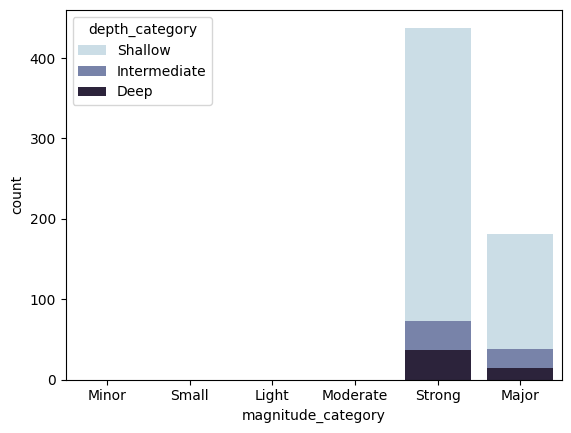

<Axes: xlabel='depth_category', ylabel='count'>

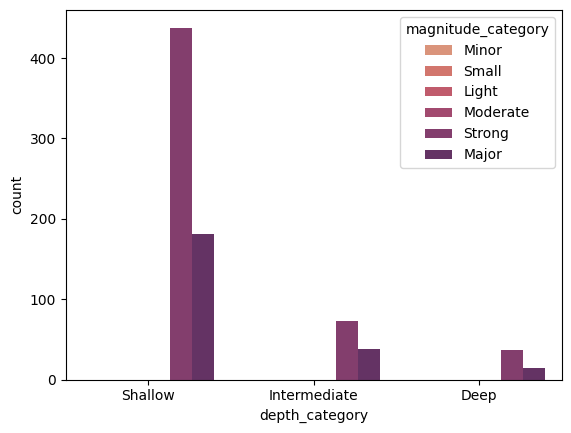

In [5]:
sns.countplot(x = 'magnitude_category', data = df_processed, hue = 'depth_category', palette = 'ch:s=.25,rot=-.25' )
plt.show()

sns.countplot( x = 'depth_category', data = df_processed, hue = 'magnitude_category',  palette = 'flare' )

EDA visualization saved: "01_eda_analysis.png"


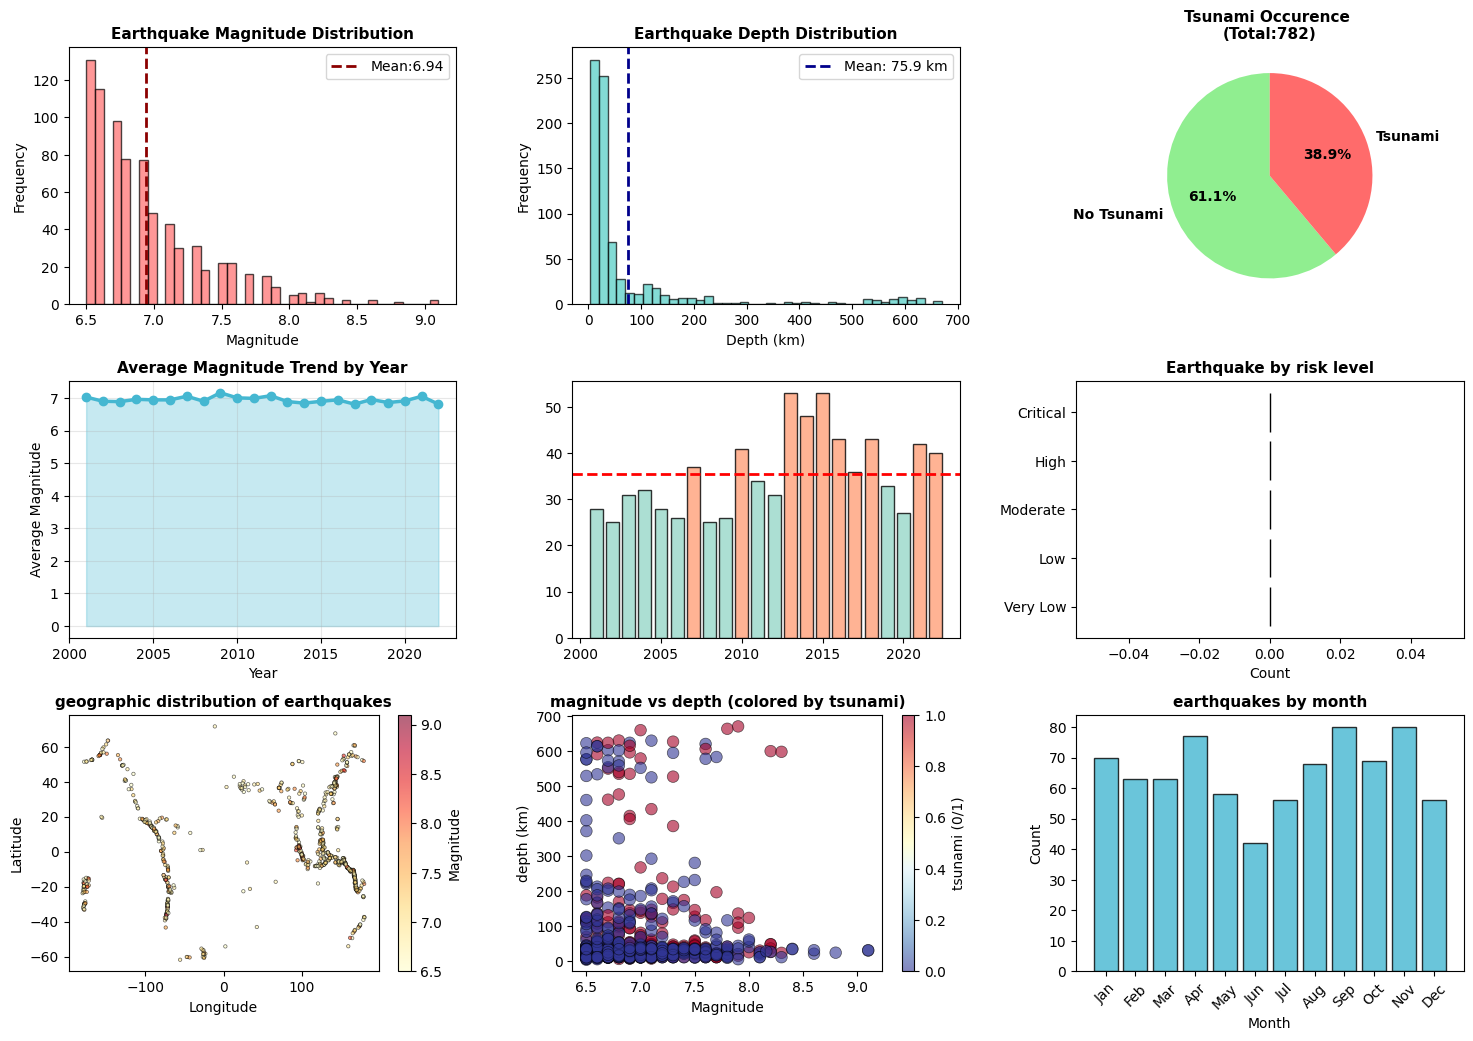

In [6]:
fig = plt.figure(figsize = (18, 12))
gs = fig.add_gridspec(3, 3, hspace = 0.3, wspace = 0.3)

#Magnitude distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_processed['magnitude'], bins = 40, color = '#FF6B6B',
         edgecolor = 'black', alpha = 0.7)

ax1.axvline(df_processed['magnitude'].mean(), color = 'darkred',
                          linestyle='--', linewidth = 2,
                          label = f'Mean:{df_processed['magnitude'].mean():.2f}')

ax1.set_title('Earthquake Magnitude Distribution', fontweight = 'bold', fontsize = 11)
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('Frequency')
ax1.legend()

#2 depth distribution

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_processed['depth'], bins = 40, color = '#4ECDC4', edgecolor = 'black', alpha = 0.7)
ax2.axvline(df_processed['depth'].mean(), color = 'darkblue', linestyle = '--', linewidth = 2,
            label = f'Mean: {df_processed['depth'].mean():.1f} km')
ax2.set_title('Earthquake Depth Distribution', fontweight = 'bold', fontsize = 11)
ax2.set_xlabel('Depth (km)')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3 tsunami distribution

ax3 = fig.add_subplot(gs[0, 2])
tsunami_counts = df_processed['tsunami'].value_counts()
colors_pie = ['#90EE90', '#FF6B6B']
ax3.pie(tsunami_counts, labels = ['No Tsunami', 'Tsunami'], autopct = '%1.1f%%',
        colors = colors_pie, startangle = 90, textprops = {'fontweight': 'bold'})
ax3.set_title(f'Tsunami Occurence \n(Total:{tsunami_counts.sum()})', fontweight = 'bold',
              fontsize = 11)

# 4 magnitude by year

ax4 = fig.add_subplot(gs[1, 0])
yearly_mag = df_processed.groupby('Year')['magnitude'].agg(['mean', 'count'])
ax4.plot(yearly_mag.index, yearly_mag['mean'], marker = 'o', linewidth = 2.5, markersize = 6,
         color = '#45B7D1')
ax4.fill_between(yearly_mag.index, yearly_mag['mean'], alpha = 0.3, color = '#45B7D1')
ax4.set_title('Average Magnitude Trend by Year', fontweight = 'bold', fontsize = 11)
ax4.set_xlabel('Year')
ax4.set_ylabel('Average Magnitude')
ax4.grid(True, alpha = 0.3)

# 5 earthquakes count by year

ax5 = fig.add_subplot(gs[1, 1])
yearly_count = df_processed.groupby('Year').size()
colors_bar = ['#FFA07A' if yearly_count[year] > yearly_count.mean()
                        else '#98D8C8' for year in yearly_count.index]
ax5.bar(yearly_count.index, yearly_count.values, color = colors_bar,
        edgecolor = 'black', alpha = 0.8)
ax5.axhline(yearly_count.mean(), color = 'red', linestyle = '--', linewidth = 2,
            label = f'Avg: {yearly_count.mean():.1f}')


#6 risk level distribbution

ax6 = fig.add_subplot(gs[1, 2])
risk_counts = df_processed['risk_level'].value_counts()
risk_colors = {'Very Low': '#90EE90', 'Low': '#FFD700', 'Moderate': '#FFA500',
               'High': '#FF6347', 'Critical': '#8B0000'}
colors_risk = [risk_colors.get(cat, '#999999') for cat in risk_counts.index]
ax6.barh(risk_counts.index, risk_counts.values, color = colors_risk,
         edgecolor = 'black')
ax6.set_title('Earthquake by risk level', fontweight = 'bold', fontsize = 11)
ax6.set_xlabel('Count')


#7 geographic distribution

ax7 = fig.add_subplot(gs[2, 0])
scatter = ax7.scatter(df_processed['longitude'], df_processed['latitude'],

                      c = df_processed['magnitude'], cmap = 'YlOrRd',s=6,
                      alpha = 0.6, edgecolors = 'black', linewidth = 0.5)

ax7.set_title('geographic distribution of earthquakes', fontweight = 'bold', fontsize = 11)
ax7.set_xlabel('Longitude')
ax7.set_ylabel('Latitude')
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Magnitude')

# 8 magnitude vs depth

ax8 = fig.add_subplot(gs[2,1])
scatter2 = ax8.scatter(df_processed['magnitude'], df_processed['depth'],
                       c = df_processed['tsunami'], cmap = 'RdYlBu_r',
                       s = 70, alpha = 0.6, edgecolors = 'black', linewidth = 0.5)
ax8.set_title('magnitude vs depth (colored by tsunami)', fontweight = 'bold',
              fontsize = 11)
ax8.set_xlabel('Magnitude')
ax8.set_ylabel('depth (km)')
cbar2 = plt.colorbar(scatter2, ax = ax8)
cbar2.set_label('tsunami (0/1)')

# 9 monthly distribution

ax9 = fig.add_subplot(gs[2,2])
monthly_data = df_processed.groupby('Month').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
               'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax9.bar(monthly_data.index, monthly_data.values, color = '#45B7D1',
        edgecolor = 'black', alpha = 0.8)
ax9.set_title('earthquakes by month', fontweight = 'bold', fontsize = '11')
ax9.set_xlabel('Month')
ax9.set_ylabel('Count')
ax9.set_xticks(range(1, 13))
ax9.set_xticklabels(month_names, rotation = 45)

plt.savefig('01_eda_analysis.png', dpi = 300, bbox_inches = 'tight')
print('EDA visualization saved: "01_eda_analysis.png"')


In [7]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [8]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [9]:
x  = df[['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month']]

In [10]:
y = df[['tsunami']]

In [11]:
mlp_clf = Pipeline([('scaler', StandardScaler()),
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes = (17, ), random_state = 42, max_iter = 5000))])

In [12]:
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
lst_accu_stratified = []

In [14]:
for train_index, test_index in skf.split(x,y):
  x_train_fold, x_test_fold = x.iloc[train_index], x.iloc[test_index]
  y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
  y_train_fold = y_train_fold.values.ravel()
  y_test_fold = y_test_fold.values.ravel()
  mlp_clf.fit(x_train_fold, y_train_fold)
  lst_accu_stratified.append(mlp_clf.score(x_test_fold, y_test_fold))

In [15]:
print('List of possible accuracy:', lst_accu_stratified)
print('\nMaximum Accuracy That can be obtained from this model is:',
	max(lst_accu_stratified)*100, '%')
print('\nMinimum Accuracy:',
	min(lst_accu_stratified)*100, '%')
print('\nOverall Accuracy:',
	mean(lst_accu_stratified)*100, '%')
print('\nStandard Deviation is:', stdev(lst_accu_stratified))

List of possible accuracy: [0.8734177215189873, 0.8860759493670886, 0.8589743589743589, 0.8846153846153846, 0.8333333333333334, 0.8846153846153846, 0.9102564102564102, 0.8974358974358975, 0.8205128205128205, 0.8333333333333334]

Maximum Accuracy That can be obtained from this model is: 91.02564102564102 %

Minimum Accuracy: 82.05128205128204 %

Overall Accuracy: 86.82570593963 %

Standard Deviation is: 0.030367561459964554
